# This example models a slower-growing yeast model (<0.28/hour) from Elsemman et al, 2022: https://doi.org/10.1038/s41467-022-28467-6

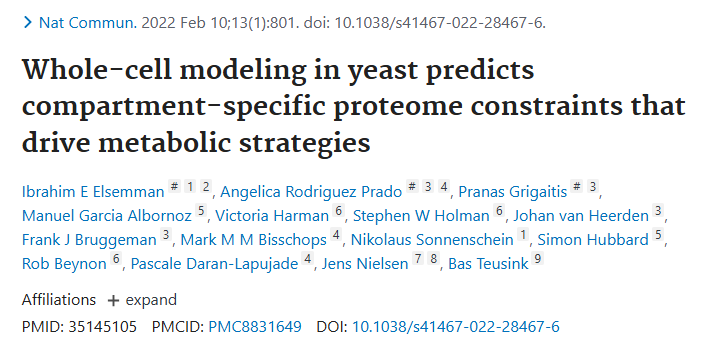

## 1. Import SIMOFF.py file from: https://github.com/katemeeson/SIMOFF
### SIMOFF.py file must be in the same folder as this Jupyter notebook for it to work

In [1]:
import SIMOFF as smf

## 2. Specify SIMOFF input
## 2a. Load COBRA model
### You can load this in from another notebook, or you can specify omics constraints/media conditions here as appropriate

In [3]:
#Zhang et al, 2024: yeast-GEM: 10.1038/s44320-024-00060-7
from cobra.io import read_sbml_model
model = read_sbml_model('yeast-GEM.xml')

## 2b. Specify the qualitative reaction criteria
### I.e. experimental measurements, which have been transformed from continuous flux measurements to a -1, 0 or +1, corresponding to metabolite exchange or little/no activity, based on reaction reversibility. Input reactions to be considered within the objective function can be any number of model reactions. Here, we made our choice based on reactions that we know CHO cells are evolved towards with cell engineering and selection strategies

In [4]:
qualitative_criteria = {'r_2111':1,'r_1714':-1,'r_1761':0,'r_1808':0,'r_1654':-1}
input_reactions = ['r_2111', 'r_1761', 'r_1808', 'r_1714', 'r_1654']

#define a minimial medium within model (or set to be your experimental culture conditions)
from cobra.medium import minimal_medium
max_growth = model.slim_optimize()
minimal = minimal_medium(model, max_growth)
minimal_dict = minimal.to_dict()
model.medium = minimal_dict
print(model.medium)

#check that the input objectives are in the media so that these metabolites can actually be transported
#if they're not in the media, then open the reactions so that they can exchange freely
#D-glucose
if 'r_1714' in minimal_dict.keys():
    print('r_1714 already defined')
elif 'r_1714' not in minimal_dict.keys():
    minimal_dict['r_1714'] = 1
    print(minimal_dict['r_1714'])

#Ethanol
if 'r_1761' in minimal_dict.keys():
    print('r_1761 already defined')
elif 'r_1761' not in minimal_dict.keys():
    minimal_dict['r_1761'] = 1
    print(minimal_dict['r_1761'])

#Glycerol
if 'r_1808' in minimal_dict.keys():
    print('r_1808 already defined')
elif 'r_1808' not in minimal_dict.keys():
    minimal_dict['r_1808'] = 1
    print(minimal_dict['r_1808'])

#Ammonium
if 'r_1654' in minimal_dict.keys():
    print('r_1654 already defined')
elif 'r_1654' not in minimal_dict.keys():
    minimal_dict['r_1654'] = 1
    print(minimal_dict['r_1654'])

model.medium = minimal_dict
print(model.medium)

{'r_1654': 0.5987757792265652, 'r_1714': 1.0, 'r_1832': 0.042355921812448995, 'r_1861': 2.629679636262737e-06, 'r_1992': 2.25005295947331, 'r_2005': 0.544948527084135, 'r_2020': 0.00030400435553062504, 'r_2049': 0.00033247859553473083, 'r_2060': 0.0072031713974737635, 'r_4593': 0.00010803461132465607, 'r_4594': 5.518977345077752e-05, 'r_4595': 0.0002286313844895006, 'r_4596': 6.264332215932059e-05, 'r_4597': 0.00010406018935736309, 'r_4600': 1.817326290786762e-05}
r_1714 already defined
1
1
r_1654 already defined
{'r_1654': 0.5987757792265652, 'r_1714': 1.0, 'r_1761': 1, 'r_1808': 1, 'r_1832': 0.042355921812448995, 'r_1861': 2.629679636262737e-06, 'r_1992': 2.25005295947331, 'r_2005': 0.544948527084135, 'r_2020': 0.00030400435553062504, 'r_2049': 0.00033247859553473083, 'r_2060': 0.0072031713974737635, 'r_4593': 0.00010803461132465607, 'r_4594': 5.518977345077752e-05, 'r_4595': 0.0002286313844895006, 'r_4596': 6.264332215932059e-05, 'r_4597': 0.00010406018935736309, 'r_4600': 1.8173262

## 3. Run SIMOFF

In [5]:
result = smf.simoff(model, input_reactions, qualitative_criteria, bounds=None, max_iter=300, initialtemp=30, maxfun=5000)
#the hyperparameters max_iter, initialtemp and maxfun are detailed on https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.dual_annealing.html and are specific to the conditions you are modelling

There are 26 possible combinations of objectives.


🔸 Running single-reaction objective tests...

   Single-objective r_2111 (maximisation) → Accuracy: 60.00%
   Single-objective r_1761 (minimisation) → Accuracy: 60.00%
   Single-objective r_1808 (minimisation) → Accuracy: 60.00%
   Single-objective r_1714 (minimisation) → Accuracy: 60.00%
   Single-objective r_1654 (minimisation) → Accuracy: 60.00%

✅ Single-objective tests complete.


🧊 Optimisation: fitting objective(s) ['r_2111', 'r_1761', 'r_1808', 'r_1714', 'r_1654'] to match 5 qualitative constraints
🔸 Running SIMOFF across different reaction combinations...

🔹 Testing combination['r_2111', 'r_1761']...

SIMOFF suggested coefficients:{'r_2111': np.float64(0.8623818908372007), 'r_1761': np.float64(-0.1376181091627993)}
Accuracy achieved:60.0%

🔹 Testing combination['r_2111', 'r_1808']...

SIMOFF suggested coefficients:{'r_2111': np.float64(0.44835956241737523), 'r_1808': np.float64(-0.5516404375826247)}
Accuracy achieved:60.0%

🔹

In [6]:
#store result so that you can reload when session is terminated
yeast_slow_tutorial_result = result
%store yeast_slow_tutorial_result

Stored 'yeast_slow_tutorial_result' (dict)


In [7]:
%store -r yeast_slow_tutorial_result

## 4. Visualise output
### This uses some additional python files that I have deposited onto the SIMOFF repository to let the User see what is happening on the way to the global optimum

### 4a. Visualising the trajectory of the reaction vector coefficients over the SIMOFF run

In [8]:
import Plot_coefficients as pltcf

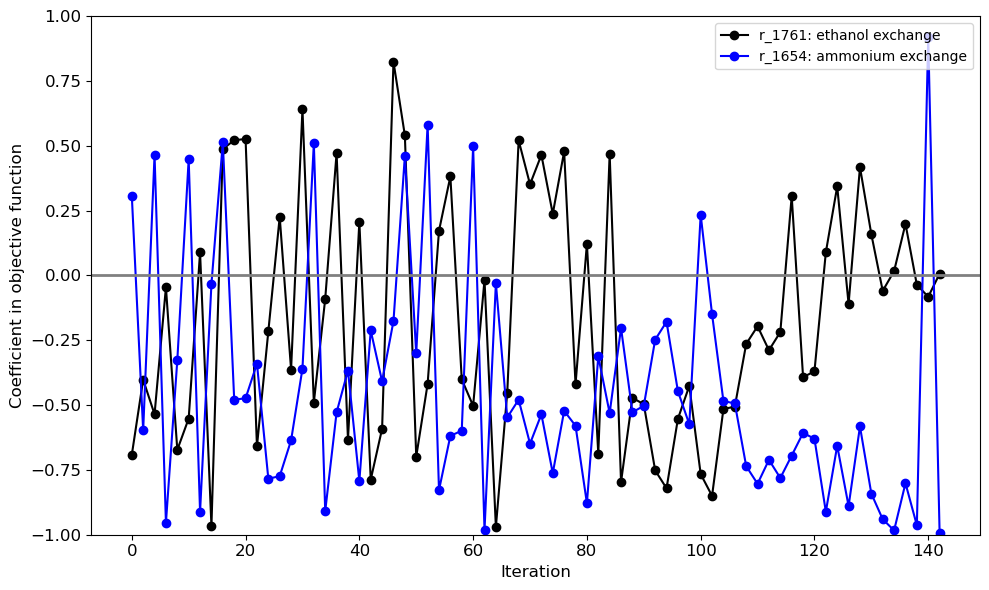

In [11]:
result = yeast_slow_tutorial_result
function_result = result['r_1761','r_1654'] #this was the successful result from SIMOFF run, that I would like to plot
plot = pltcf.plot_coefficients(function_result, model, step=2)

### 4b. Visualising the mismatch of FBA to experimental, qualitative criteria over the SIMOFF run

In [12]:
import Mismatch_grid as mmg

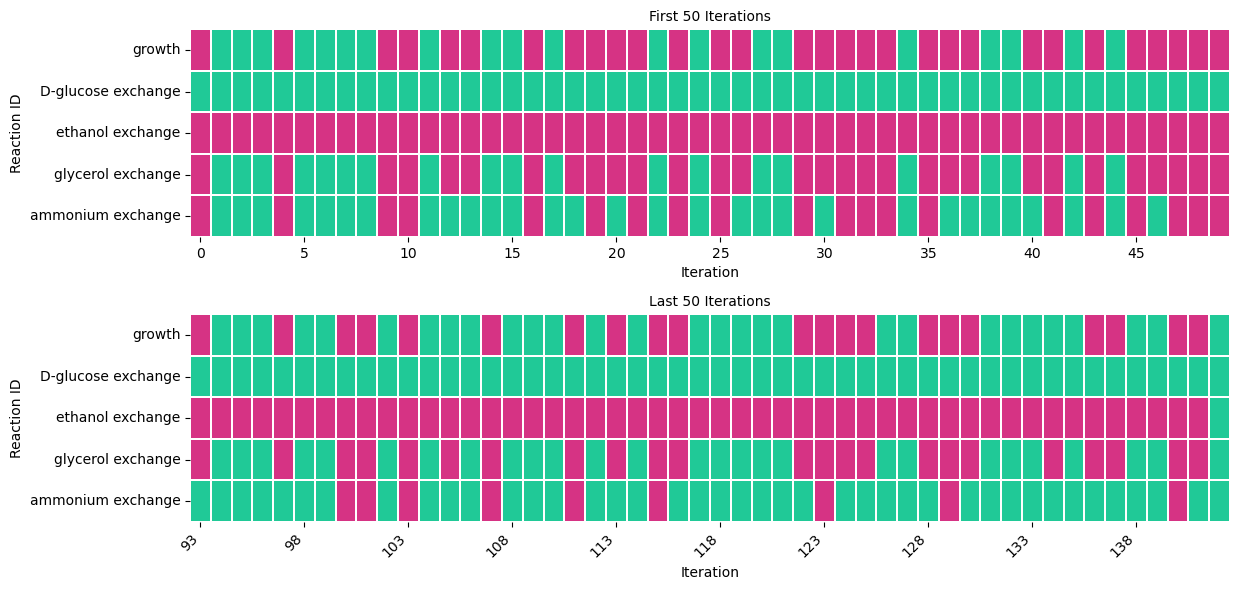

In [13]:
grid = mmg.mismatch(function_result, model, num_columns=50)

### 4c. Visualise upset-style plot to observe accuracy achieved for each combination of objective reactions

In [14]:
import Upset_plot as upst

C:\Users\p04121km\AppData\Local\anaconda3\envs\prosperity_project\Lib\site-packages\upsetplot\plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
C:\Users\p04121km\AppData\Local\anaconda3\envs\prosperity_project\Lib\site-packages\upsetplot\plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the in

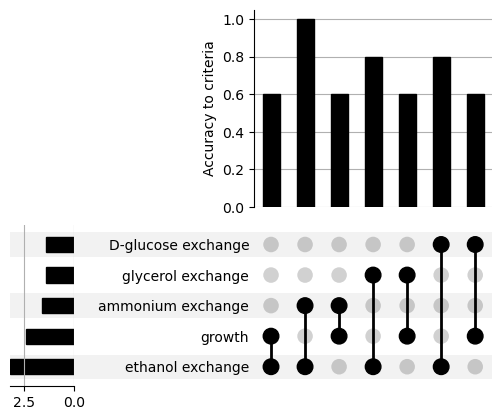

In [15]:
upset = upst.upset(result, model, input_reactions)